### Figure 4

This code generates Figure 4 of the paper. This figure compares mRNA expression correlation between TF-target genes for biologically relevant binding targets and spurious targets <br>
<br>
INPUT:<br>
processed/ExpDecayConst_params.csv : Parameters for two-state model for each dataset<br>
processed/Compiled_accessible_target_ChIP_peaks.csv: Cumulative positional distribution of<br>
TF binding events
<br>
<br>
OUTPUT: <br>
Figure4.pdf <br>





In [1]:
#Load require
import os 
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from scipy.stats import linregress, spearmanr, fisher_exact,pearsonr
from scipy.optimize import curve_fit
from math import exp,log
from scipy.stats import norm
from utils import *
import patchworklib as pw
from random import choices
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import *
from statannot import add_stat_annotation
import seaborn as sns
font_size = 30
point_size = 5

sns.set_context("paper", rc={"font.size":font_size,"axes.titlesize":font_size,"axes.labelsize":font_size, 
                             "axes.ticklabelsize":font_size})   

labels = ['Non-functional\n> 2kb', 'Non-functional\n< 2kb', 'Functional']

def any_not_all(x):
    return (any(x) & (not all(x)))


#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE"
os.chdir(working_dir)

<Figure size 72x72 with 0 Axes>

In [2]:
#Load compiled peak distribution and parameters for each fit
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)
df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)

#Merge parameters for each cell line
df = df.merge(params,on=['TF','CellLine'])

#Reference annotation file
TSS_ref = pd.read_table('TF_TSS_10kb_named.bed')
TSS_ref['TSS'] = TSS_ref['end']-10000

## Load RNA-seq data for TF-target genes

In [3]:
compiled_correlation = pd.DataFrame()
for ids,row in params.loc[params.CellLine == 'K562'].iterrows():
    file = row['CellLine'] +'/ChIP-seq/' + row['TF'] + '_consensus_accessible_peaks_named.bed'
    
    #Load file for TF in cell line
    df =  pd.read_table(file,
                        names = ['chrom','start','end','Gene'])
    df =  df[['chrom','start','end','Gene']]
    df = df.drop_duplicates()
    
    #Get distance of peak from TSS
    df=df.merge(TSS_ref[['TSS','Gene']])
    df['start_diff'] =  df['start'] - df['TSS']
    df['end_diff'] =  df['end'] - df['TSS']
    df['min_dist'] = df.apply(lambda x: abs(sum([x['start_diff'], x['end_diff']])/2), axis =1)
    df = df.loc[df.min_dist <=10000]        
    
    #Calculate threshold within which true binding to spurious binding ratio is 10. 
    t = n_max_true(row.rb,row.tau,row.rs, [0.1]).Distance

    df['Threshold'] = df.min_dist <= t.values[0]
    df['Threshold_2kb'] = df.min_dist <= 2000
    

    #Obtain RNA-seq data
    genes = df.groupby('Gene')['Threshold'].apply(any).reset_index(name ='Threshold')
    genes['Threshold_2kb'] = df.groupby('Gene')['Threshold_2kb'].apply(any).values
    rnaseq = pd.read_csv('RNA-seq/Compiled_RNAseq.csv',index_col =0)
    rnaseq.index = rnaseq.Gene
    rnaseq= rnaseq.drop('Gene', axis =1).T
    genes = genes.loc[genes.Gene.isin(rnaseq.columns)]
    corr = [list(spearmanr(rnaseq[row['TF']],rnaseq[i])) + 
            [genes.Threshold.iloc[idx],genes.Threshold_2kb.iloc[idx], i,row['TF'], row['CellLine']] for idx,i in enumerate(genes.Gene)]
    corr =pd.DataFrame(corr, columns = ['Correlation','pval', 'Threshold','Threshold_2kb', 'Gene', 'TF','CellLine'])
    compiled_correlation = pd.concat([compiled_correlation, corr])

#Classify genes as biologically relevant and spurious targets
compiled_correlation['Correlation_thresh'] = (abs(compiled_correlation['Correlation']) > 0.5) & (compiled_correlation['pval'] < 0.05) 
compiled_correlation['Threshold'] = [ labels[2] if i else labels[0]  for i in compiled_correlation['Threshold'] ]
compiled_correlation['corr_abs'] = abs(compiled_correlation.Correlation)

#Classify genes that are considered "biologically-relevant" under fixed threshold model
compiled_correlation['Threshold_category'] = (compiled_correlation.Threshold == labels[2]) &(compiled_correlation.Threshold_2kb)

compiled_correlation['Threshold_category'].loc[compiled_correlation.Threshold_2kb & 
                                              ~compiled_correlation['Threshold_category']] = labels[1]
compiled_correlation['Threshold_category'].loc[compiled_correlation['Threshold_category'] == True] = labels[2]
compiled_correlation['Threshold_category'].loc[compiled_correlation['Threshold_category']== False] = labels[0]


fill = compiled_correlation.groupby(['TF','Threshold_category']).apply(lambda x : x['Correlation_thresh'].sum()/len(x['Correlation_thresh']) ).reset_index()
fill.columns = ['TF','Threshold_category','Fraction']

In [4]:
compiled_correlation.groupby(['Threshold','Threshold_2kb','Correlation_thresh']).size()

Threshold              Threshold_2kb  Correlation_thresh
Functional             True           False                  94163
                                      True                  103759
Non-functional\n> 2kb  False          False                 108972
                                      True                   14929
                       True           False                  25267
                                      True                    6457
dtype: int64

In [5]:
compiled_correlation.groupby(['Threshold','Threshold_2kb']).size()

Threshold              Threshold_2kb
Functional             True             197922
Non-functional\n> 2kb  False            123901
                       True              31724
dtype: int64

([<matplotlib.patches.Wedge at 0x7f6274adc310>,
 [Text(0.49799948049002, 0.9808142114751756, 'Spurious > 2kb'),
  Text(-0.7511844227646087, -0.8035682690324463, 'Biologically \nRelevant'),
  Text(1.0565824128020693, -0.3059960865066047, 'Spurious < 2kb')],
 [Text(0.2716360802672836, 0.5349895698955502, '35.0%'),
  Text(-0.4097369578716047, -0.4383099649267888, '56.0%'),
  Text(0.5763176797102196, -0.16690695627632982, '9.0%')])

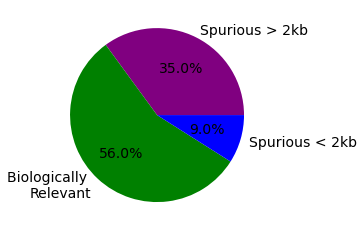

In [6]:
labels =  ['Spurious > 2kb', 'Biologically \nRelevant', 'Spurious < 2kb']
sizes = [123901,197922,31724]

colors = ['purple', 'green', 'blue']

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
      textprops={'fontsize': 14},colors = colors)

([<matplotlib.patches.Wedge at 0x7f62731078d0>,
 [Text(0.8826799239431912, 0.6564115720092407, 'Correlated'),
  Text(-0.8826799239431912, -0.6564115720092407, 'Not correlated')],
 [Text(0.481461776696286, 0.35804267564140396, '20.4%'),
  Text(-0.481461776696286, -0.35804267564140396, '79.6%')])

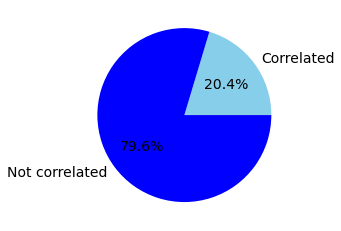

In [7]:
labels =  ['Correlated', 'Not correlated']
sizes = [6457,25267]

colors = ['skyblue','blue']

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%',
      textprops={'fontsize': 14}, colors = colors)

## Plot Figure 4A and 4B

In [8]:
labels = ['Non-functional\n> 2kb', 'Non-functional\n< 2kb', 'Functional']
my_pal = {labels[0]: "m", labels[1]:"b", labels[2] : "g"}

compiled_correlation['Threshold_category'] = pd.Categorical(compiled_correlation['Threshold_category'] ,
                                                           ['Non-functional\n> 2kb', 'Non-functional\n< 2kb', 'Functional'])
fig4B = pw.Brick(figsize=(6,4))
#sns.boxplot(data=compiled_correlation
#            ,x='Threshold', y = "corr_abs", ax = fig4B, palette = my_pal)
sns.violinplot(data=compiled_correlation
            ,x='Threshold_category', y = "corr_abs",ax = fig4B,  palette = my_pal)
fig4B.set(
    xlabel='\n', 
    ylabel="|Spearman's $\\rho$|"
)

plt.setp(fig4B.get_xticklabels(), ha='right', va ='top')
fig4B.tick_params(labelsize=18,rotation = 30, left = True,
                 labelleft = True)
fig4B.axhline(y=0.5,color='black', linestyle='--')
fig4B, test_results = add_stat_annotation(fig4B,data=compiled_correlation,x='Threshold_category', y = "corr_abs" ,
                                   box_pairs=[(labels[0], labels[1]),
                                             (labels[0], labels[2]),
                                             (labels[2], labels[1])],
                                   line_offset_to_box=0.1, line_offset=0.1, 
                                    fontsize=16,line_height=0.01, text_offset=2,
                                   test='t-test_ind', text_format='star', loc='inside', verbose=2)
fig4B.set_yticks([0,0.5,1])
fig4B.set_ylim(bottom=0)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Non-functional
> 2kb v.s. Non-functional
< 2kb: t-test independent samples with Bonferroni correction, P_val=2.398e-179 stat=-2.865e+01
Non-functional
< 2kb v.s. Functional: t-test independent samples with Bonferroni correction, P_val=0.000e+00 stat=-9.035e+01
Non-functional
> 2kb v.s. Functional: t-test independent samples with Bonferroni correction, P_val=0.000e+00 stat=-1.991e+02


(0.0, 1.671236991987165)

<Figure size 432x288 with 0 Axes>

In [9]:
fig4A = pw.Brick(figsize=(6,4))
fill['Threshold_category'] = pd.Categorical(fill['Threshold_category'] ,
                                            ['Non-functional\n> 2kb', 'Non-functional\n< 2kb', 'Functional'])
sns.boxplot(data=fill,x='Threshold_category', y = "Fraction",ax=fig4A, palette = my_pal)

fig4A.set(
    xlabel='\n', 
    ylabel='Fraction of genes with\ncorrelated expression'
)
fig4A.tick_params(labelsize=22,rotation = 30, bottom=False)
fig4A.set(xticklabels=[])
fig4A, test_results = add_stat_annotation(fig4A,data=fill,x='Threshold_category', y = "Fraction" ,
                                   box_pairs=[(labels[0], labels[1]),
                                             (labels[0], labels[2]),
                                             (labels[2], labels[1])],
                                   line_offset_to_box=0.1, line_offset=0.1, 
                                    fontsize=16,line_height=0.01, text_offset=2,
                                   test='t-test_paired', text_format='star', loc='inside', verbose=2)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

Non-functional
> 2kb v.s. Non-functional
< 2kb: t-test paired samples with Bonferroni correction, P_val=3.005e-06 stat=-8.217e+00
Non-functional
< 2kb v.s. Functional: t-test paired samples with Bonferroni correction, P_val=3.820e-10 stat=-1.665e+01
Non-functional
> 2kb v.s. Functional: t-test paired samples with Bonferroni correction, P_val=3.563e-11 stat=-1.985e+01


<Figure size 432x288 with 0 Axes>

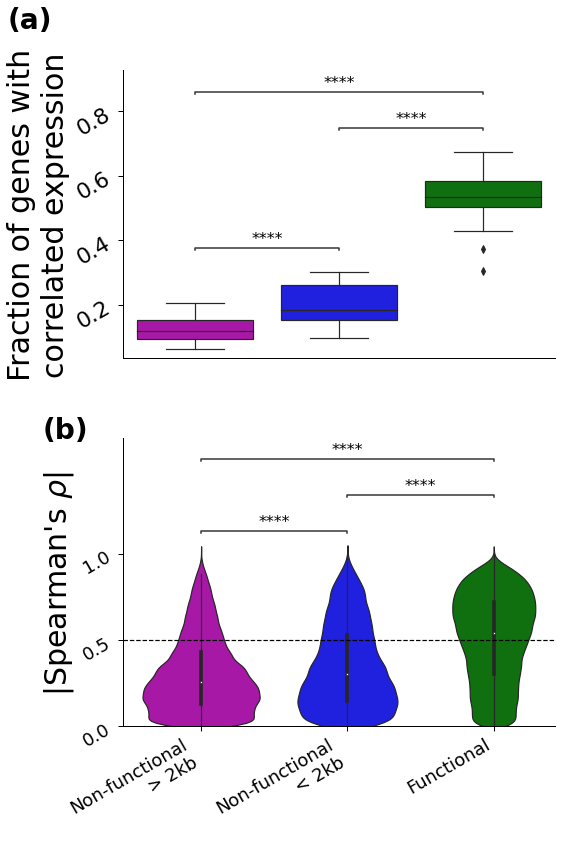

In [10]:
sns.despine(ax = fig4B)
sns.despine(ax = fig4A)

fig4A.set_index('(a)',size = 28,fontweight="bold",x = 0)
fig4B.set_index('(b)',size = 28,fontweight="bold", x=0)


fig4 = (fig4A / fig4B)
fig4.savefig('../../Figures/Figure4.pdf')

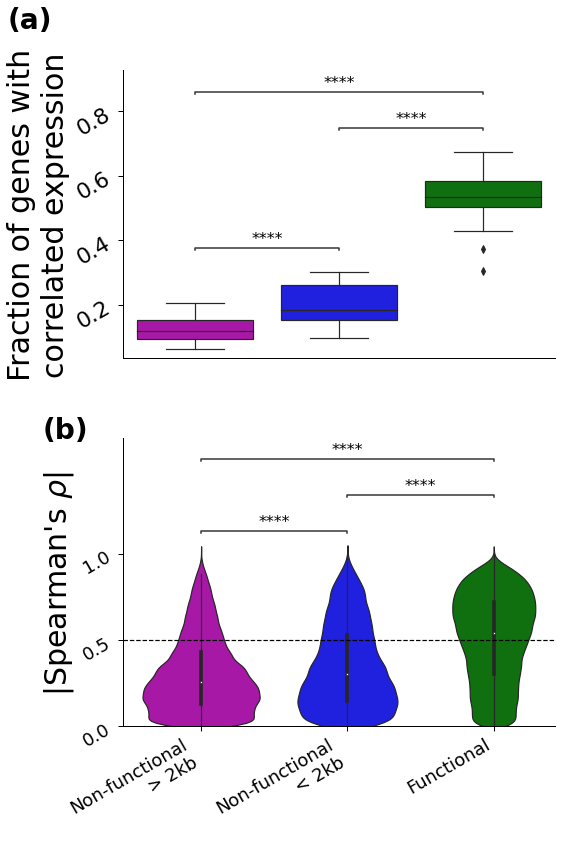

In [11]:
fig4.savefig('/home/mpf1405/Revision/Figure4.pdf')